<a href="https://colab.research.google.com/github/riyaarawat/medical-insurance-cost-prediction/blob/main/medical_insurance_cost_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!git clone https://github.com/riyaarawat/medical-insurance-cost-prediction.git
%cd medical-insurance-cost-prediction
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.describe(include='object')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

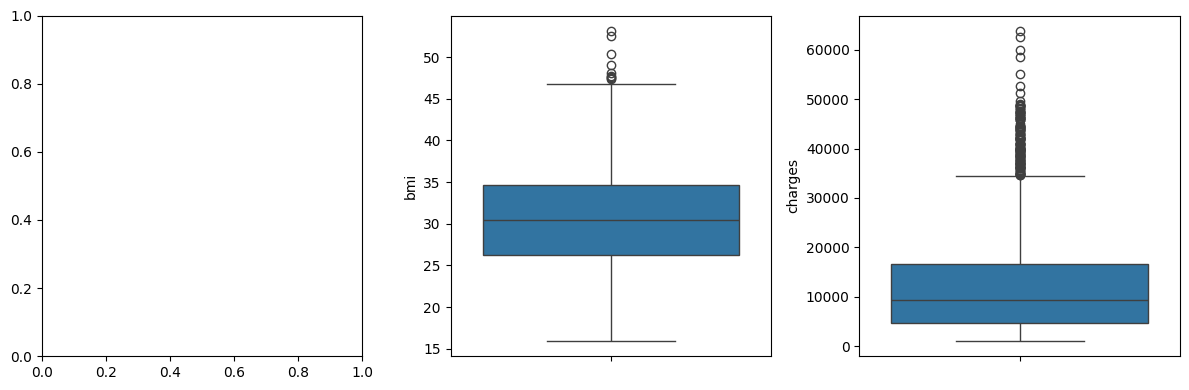

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(Y=df['age'])

plt.subplot(1,3,2)
sns.boxplot(y=df['bmi'])

plt.subplot(1,3,3)
sns.boxplot(y=df['charges'])

plt.tight_layout()
plt.show()

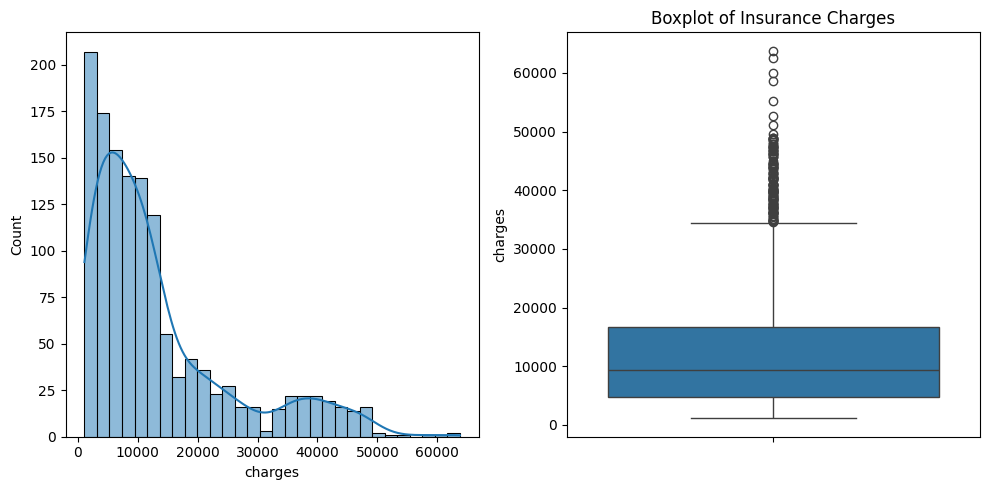

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.histplot(df['charges'], bins=30, kde=True)

plt.subplot(1,2,2)
sns.boxplot(y=df['charges'])
plt.title('Boxplot of Insurance Charges')

plt.tight_layout()
plt.show()

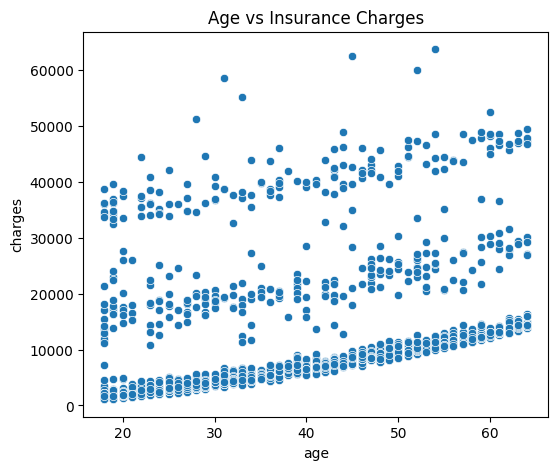

In [ ]:
plt.figure(figsize=(6,5))

sns.scatterplot(x='age', y='charges', data=df)
plt.title('Age vs Insurance Charges')
plt.show()

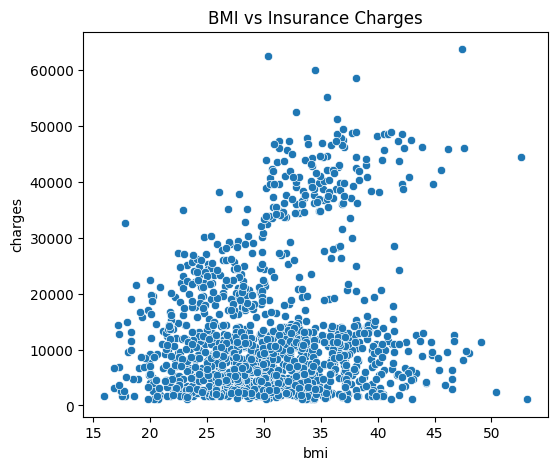

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='bmi',y='charges',data=df)
plt.title('BMI vs Insurance Charges')
plt.show()

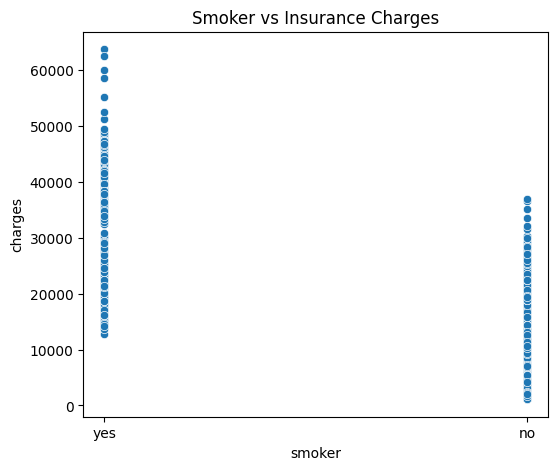

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='smoker',y='charges',data=df)
plt.title('Smoker vs Insurance Charges')
plt.show()

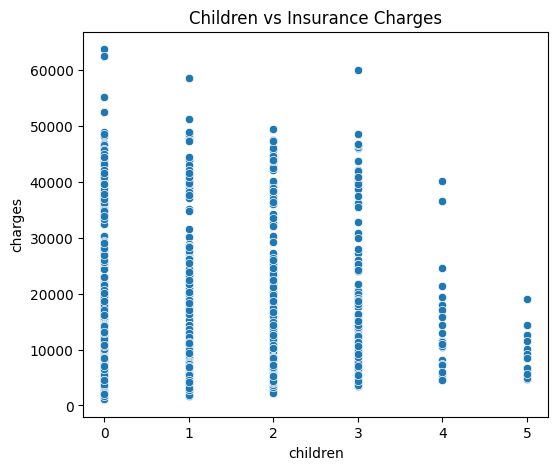

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='children',y='charges',data=df)
plt.title('Children vs Insurance Charges')
plt.show()

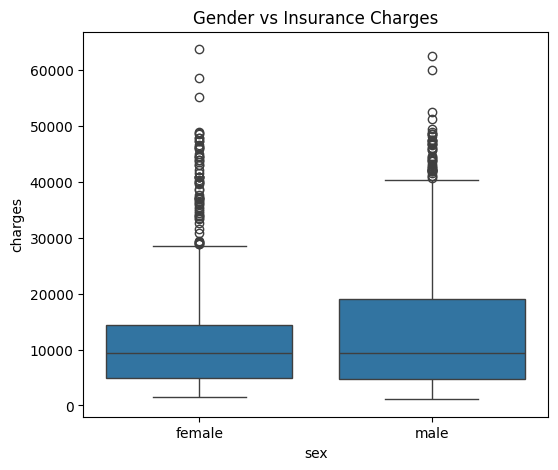

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x='sex',y='charges',data=df)
plt.title('Gender vs Insurance Charges')
plt.show()

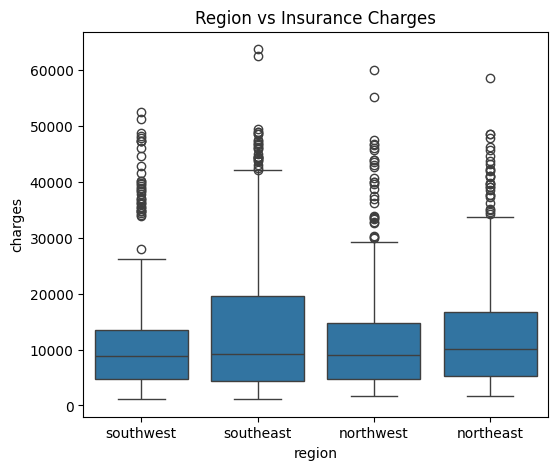

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x='region',y='charges',data=df)
plt.title('Region vs Insurance Charges')
plt.show()

In [ ]:
df_corr = df.copy()
df_corr['smoker'] = df_corr['smoker'].map({
    'no': 0,
    'yes': 1
})
df_corr['sex'] = df_corr['sex'].map({
    'female' : 0,
    'male' : 1
})

corr_matrix = df_corr.select_dtypes(include='number').corr()
corr_matrix

,age,sex,bmi,children,smoker,charges
age,1.000000,-0.019814,0.109344,0.041536,-0.025587,0.298308
sex,-0.019814,1.000000,0.046397,0.017848,0.076596,0.058044
bmi,0.109344,0.046397,1.000000,0.012755,0.003746,0.198401
children,0.041536,0.017848,0.012755,1.000000,0.007331,0.067389
smoker,-0.025587,0.076596,0.003746,0.007331,1.000000,0.787234
charges,0.298308,0.058044,0.198401,0.067389,0.787234,1.000000


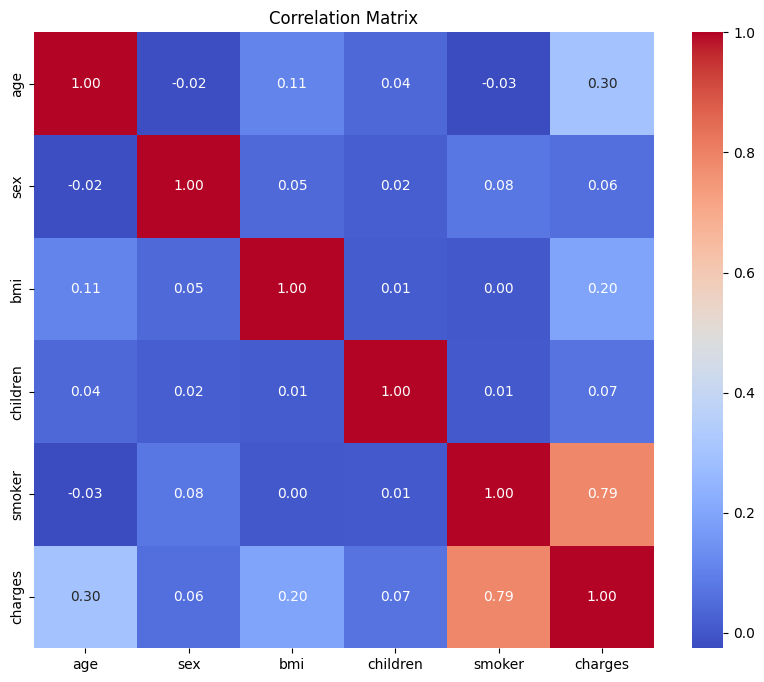

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df['sex'] = df['sex'].map({
    'male' : 0,
    'female' : 1
})

df['smoker'] = df['smoker'].map({
    'no' : 0,
    'yes' : 1
})

df = pd.get_dummies(df,columns=['region'],drop_first=True,dtype=int)

df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,1
1,18,0,33.770,1,0,1725.55230,0,1,0
2,28,0,33.000,3,0,4449.46200,0,1,0
3,33,0,22.705,0,0,21984.47061,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0


In [ ]:
X = df.drop('charges',axis=1)
y = df['charges']


In [ ]:
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,0,0,1
1,18,0,33.770,1,0,0,1,0
2,28,0,33.000,3,0,0,1,0
3,33,0,22.705,0,0,1,0,0
4,32,0,28.880,0,0,1,0,0


In [ ]:
y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1069, 8)
X_test : (268, 8)
y_train: (1069,)
y_test : (268,)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

[[-1.1576804  -0.97140947 -0.99692768 -0.90790804 -0.50029231 -0.57266946
  -0.60581158 -0.57410974]
 [-1.30061876 -0.97140947 -0.79276204  0.7669042  -0.50029231 -0.57266946
  -0.60581158 -0.57410974]
 [ 0.91492586  1.029432    1.15466402  0.7669042  -0.50029231  1.74620801
  -0.60581158 -0.57410974]
 [ 1.70108686 -0.97140947  1.80683684 -0.90790804 -0.50029231 -0.57266946
   1.65067825 -0.57410974]
 [ 0.55757996  1.029432   -0.6514166   0.7669042  -0.50029231 -0.57266946
  -0.60581158 -0.57410974]]


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled,y_train)

coefficients = pd.DataFrame({'Feature' : X_train.columns,
                             'Coefficient' : model.coef_})
coefficients

,Feature,Coefficient
0,age,3472.975553
1,sex,50.749675
2,bmi,1927.828251
3,children,636.501185
4,smoker,9234.342487
5,region_northwest,-168.944439
6,region_southeast,-371.780810
7,region_southwest,-284.610396


In [ ]:
print('Intercept', model.intercept_)

Intercept 13030.203369289053


In [ ]:
y_pred = model.predict(X_test_scaled)

comparison = pd.DataFrame({
    'Actual' : y_test,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
900,8688.85885,8143.693884
1064,5708.86700,5737.115683
1256,11436.73815,14369.314876
298,38746.35510,31745.513636
237,4463.20510,8962.386657
481,9304.70190,13149.722353
240,38511.62830,30446.760679
277,2150.46900,1453.288813
415,7345.72660,10633.018402
707,10264.44210,11318.943794


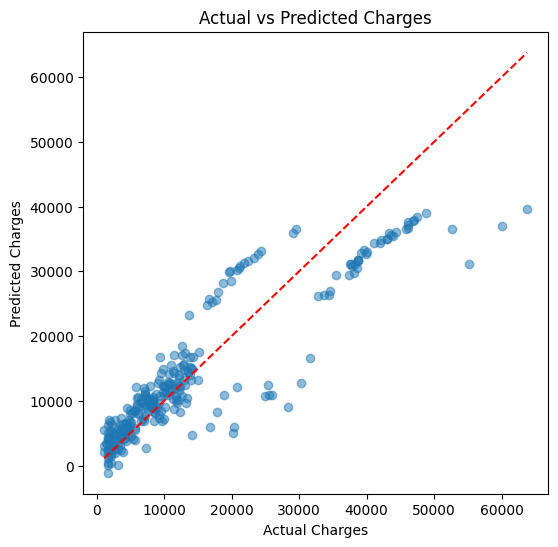

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred,alpha=0.5)

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color = 'red',
    linestyle = '--'
)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

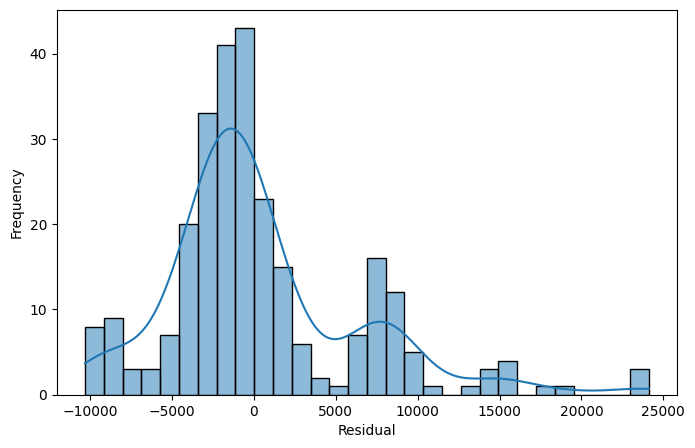

In [ ]:
residuals= y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel('Residual')
plt.ylabel('Frequency')

plt.show()

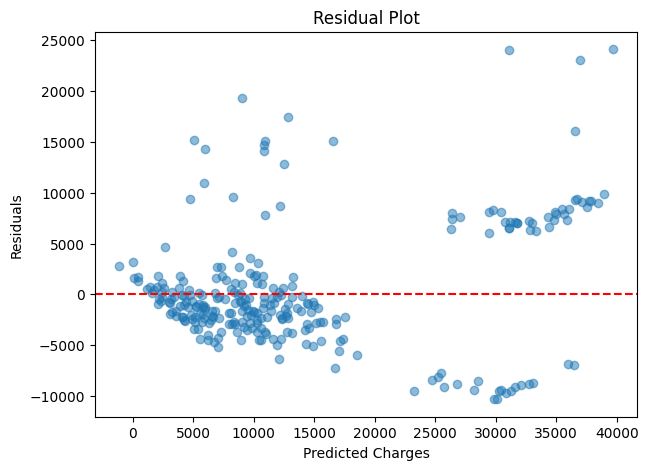

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

ridge_pred = ridge_model.predict(X_test_scaled)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

In [ ]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train_scaled, y_train)
lasso_pred = lasso_model.predict(X_test_scaled)
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

In [ ]:
from sklearn.model_selection import GridSearchCV

models_to_tune = {
    'Ridge': {
        'estimator': Ridge(),
        'param_grid': {'alpha': [0.01, 0.1, 1, 10, 100]}
    },
    'Lasso': {
        'estimator': Lasso(),
        'param_grid': {'alpha': [0.01, 0.1, 1, 10, 100]}
    }
}

results = {}

for model_name, config in models_to_tune.items():
    print(f"\n--- Tuning {model_name} Regression ---")
    estimator = config['estimator']
    param_grid = config['param_grid']

    # Initialize GridSearchCV
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=5,
        scoring='r2'
    )

    # Fit GridSearchCV to the scaled training data
    grid_search.fit(X_train_scaled, y_train)

    # Store and print best parameters and score
    best_alpha = grid_search.best_params_['alpha']
    best_score = grid_search.best_score_
    print(f"Best Alpha ({model_name}): {{'alpha': {best_alpha}}}")
    print(f"Best Cross Validation R² ({model_name}): {best_score:.4f}")

    # Train the best model with the optimal alpha
    best_model = estimator.__class__(alpha=best_alpha)
    best_model.fit(X_train_scaled, y_train)

    # Make predictions using the best model
    best_pred = best_model.predict(X_test_scaled)

    # Evaluate the best model
    mae = mean_absolute_error(y_test, best_pred)
    mse = mean_squared_error(y_test, best_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, best_pred)

    print(f"MAE (Best {model_name}): {mae:.2f}")
    print(f"MSE (Best {model_name}): {mse:.2f}")
    print(f"RMSE (Best {model_name}): {rmse:.2f}")
    print(f"R² (Best {model_name}): {r2:.4f}")

    results[model_name] = {
        'best_alpha': best_alpha,
        'best_cv_r2': best_score,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'best_model': best_model
    }



--- Tuning Ridge Regression ---
Best Alpha (Ridge): {'alpha': 10}
Best Cross Validation R² (Ridge): 0.7259
MAE (Best Ridge): 4202.58
MSE (Best Ridge): 35828958.09
RMSE (Best Ridge): 5985.73
R² (Best Ridge): 0.8050

--- Tuning Lasso Regression ---
Best Alpha (Lasso): {'alpha': 100}
Best Cross Validation R² (Lasso): 0.7258
MAE (Best Lasso): 4202.29
MSE (Best Lasso): 36319439.12
RMSE (Best Lasso): 6026.56
R² (Best Lasso): 0.8023


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MAE": [
        mae,
        ridge_mae,
        lasso_mae
    ],
    "MSE": [
        mse,
        ridge_mse,
        lasso_mse
    ],
    "RMSE": [
        rmse,
        ridge_rmse,
        lasso_rmse
    ],
    "R²": [
        r2,
        ridge_r2,
        lasso_r2
    ]
})

comparison

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,4202.288824,3.631944e+07,6026.561135,0.802350
1,Ridge Regression,4179.621622,3.551247e+07,5959.234416,0.806741
2,Lasso Regression,4177.213798,3.548536e+07,5956.959372,0.806889


In [ ]:
coef_comparison = pd.DataFrame({
    "Feature": X_train.columns,
    "Linear": model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
})

coef_comparison

,Feature,Linear,Ridge,Lasso
0,age,3472.975553,3469.695902,3472.238851
1,sex,50.749675,49.953113,49.583252
2,bmi,1927.828251,1925.755429,1926.241617
3,children,636.501185,636.297225,635.589341
4,smoker,9234.342487,9225.380712,9233.210134
5,region_northwest,-168.944439,-168.612468,-165.759506
6,region_southeast,-371.780810,-369.894956,-368.036973
7,region_southwest,-284.610396,-283.873908,-281.289926


In [ ]:
print("Best Model : Linear Regression")

Best Model : Linear Regression


In [ ]:
import joblib

joblib.dump(model, 'insurance_cost_ml_model.pkl')
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
print('Predict Insurance Charges')

age = int(input("Enter age: "))
sex = input("Enter sex (male/female): ").lower()
bmi = float(input("Enter BMI: "))
children = int(input("Enter number of children: "))
smoker = input("Is the person a smoker? (yes/no): ").lower()
region_input = input("Enter region (southwest, southeast, northwest, northeast): ").lower()

if sex == 'female':
  sex = 1
else:
  sex = 0

if smoker == 'yes':
  smoker = 1
else:
  smoker = 0

region_northwest = 1 if region_input == 'northwest' else 0
region_southeast = 1 if region_input == 'southeast' else 0
region_southwest = 1 if region_input == 'southwest' else 0

new_data = pd.DataFrame([[age, sex, bmi, children, smoker, region_northwest, region_southeast, region_southwest]],
                        columns=X_train.columns)

new_data_scaled = scaler.transform(new_data)

predicted_charge = model.predict(new_data_scaled)

print(f"\nPredicted Insurance Charge: ${predicted_charge[0]:.2f}")

Predict Insurance Charges
Enter age: 50
Enter sex (male/female): male
Enter BMI: 27
Enter number of children: 2
Is the person a smoker? (yes/no): no
Enter region (southwest, southeast, northwest, northeast): southwest

Predicted Insurance Charge: $10228.16
